<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/pipeline_evaporation_and_gas_dissolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# Finite-rate evaporation and gas dissolution in pipelines

This tutorial calculates **distance to a stated transfer criterion** for:

- hydrocarbon-liquid droplets evaporating into gas,
- a hydrocarbon wall film evaporating into gas,
- gas bubbles dissolving into oil,
- gas bubbles dissolving into water, and
- pipes that end before the dispersed phase reaches the criterion.

The model couples multicomponent Maxwell–Stefan mass transfer, interfacial heat
transfer, external wall heat transfer, changing interfacial area, and phase slip.
All examples use SI units except pressure, which is entered as bara in NeqSim.

## What you will learn

After running the notebook, you can:

1. distinguish equilibrium solubility from finite-rate dissolution length;
2. calculate droplet, film, and bubble transfer profiles;
3. interpret Maxwell–Stefan component fluxes and their sign convention;
4. compare specified and terminal-velocity slip closures;
5. report an incomplete result without pretending that a phase disappeared; and
6. check conservation and axial-step sensitivity before using a completion distance.

> **API status.** The pipeline phase-transfer API was introduced in
> [equinor/neqsim#2519](https://github.com/equinor/neqsim/pull/2519). The setup
> cell uses a released NeqSim JAR when it contains the API. Otherwise, it builds
> the exact reviewed source commit used by this notebook. The source build can
> take several minutes in a new Colab runtime.

## Model and completion definition

For component $i$, the local interfacial flux $N_i$ is positive from gas to liquid.
The axial gas balance is

$$
\frac{d\dot n_i^g}{dz}=-N_i a_i,
$$

where $a_i$ is interfacial area per pipe length. Therefore, evaporation normally
has negative flux for the injected liquid components, while dissolution normally
has positive flux for the injected gas components.

The interface calculation uses fugacity-based equilibrium and a multicomponent
Maxwell–Stefan transport matrix. This matters when counter-diffusion and mixture
coupling make a single Fick coefficient inadequate. Interfacial sensible and
latent heat transfer are solved with the species fluxes; an optional wall term
adds heat exchange with the surroundings.

The tracked dispersed-phase mass fraction is

$$
f_{\mathrm{tr}}(z)=
\frac{\sum_i n_{i,\mathrm{tr}}(z)M_i}
{\sum_i n_{i,\mathrm{tr}}(0)M_i}.
$$

For a chosen tolerance $\epsilon$, the reported completion length is

$$
L_\epsilon=\inf\{z:f_{\mathrm{tr}}(z)\leq\epsilon\}.
$$

This is a numerical engineering criterion, not literal zero mass. If the pipe
ends with $f_{\mathrm{tr}}>\epsilon$, completion is false and the distance is
NaN; the outlet still contains both model phases.

In [1]:
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import subprocess
import sys
import zipfile


REQUIRED_NEQSIM_COMMIT = "55e3d6ccc01149df1c2d665cef9f5e4aa5b052e4"
FEATURE_CLASS = (
    "neqsim/process/equipment/pipeline/evaporation/"
    "PipelineDissolutionStudy.class"
)
SOURCE_DIRECTORY = Path("/tmp/neqsim-pipeline-phase-transfer-source")
CLASSPATH_OVERRIDE = os.environ.get("NEQSIM_PIPELINE_CLASSPATH")
BUILD_JAR = None

if CLASSPATH_OVERRIDE:
    import jpype

    classpath = CLASSPATH_OVERRIDE.split(os.pathsep)
    if not jpype.isJVMStarted():
        jpype.startJVM(classpath=classpath)

    jneqsim = jpype.JPackage("neqsim")
    NEQSIM_BUILD = "local validation classpath"
else:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--upgrade",
            "neqsim",
            "pandas",
            "matplotlib",
        ]
    )

    package_spec = importlib.util.find_spec("neqsim")
    package_directory = Path(package_spec.submodule_search_locations[0])
    installed_jars = sorted((package_directory / "lib").glob("*.jar"))
    release_has_feature = any(
        FEATURE_CLASS in zipfile.ZipFile(jar_path).namelist()
        for jar_path in installed_jars
    )

    if release_has_feature:
        from neqsim import jneqsim

        NEQSIM_BUILD = importlib.metadata.version("neqsim")
    else:
        if not SOURCE_DIRECTORY.exists():
            subprocess.check_call(
                [
                    "git",
                    "clone",
                    "--filter=blob:none",
                    "--no-checkout",
                    "https://github.com/equinor/neqsim.git",
                    str(SOURCE_DIRECTORY),
                ]
            )
            subprocess.check_call(
                [
                    "git",
                    "-C",
                    str(SOURCE_DIRECTORY),
                    "fetch",
                    "--depth",
                    "1",
                    "origin",
                    REQUIRED_NEQSIM_COMMIT,
                ]
            )
            subprocess.check_call(
                [
                    "git",
                    "-C",
                    str(SOURCE_DIRECTORY),
                    "checkout",
                    "--detach",
                    REQUIRED_NEQSIM_COMMIT,
                ]
            )

        subprocess.check_call(
            [
                str(SOURCE_DIRECTORY / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dspotless.skip=true",
                "-Dcheckstyle.skip=true",
                "-Dpmd.skip=true",
                "-Dspotbugs.skip=true",
                "package",
            ],
            cwd=SOURCE_DIRECTORY,
        )

        jar_candidates = [
            jar_path
            for jar_path in (SOURCE_DIRECTORY / "target").glob("*.jar")
            if "sources" not in jar_path.name
            and "javadoc" not in jar_path.name
            and not jar_path.name.startswith("original-")
        ]
        BUILD_JAR = max(
            jar_candidates,
            key=lambda jar_path: jar_path.stat().st_size,
        )

        import jpype

        if not jpype.isJVMStarted():
            jpype.startJVM(classpath=[str(BUILD_JAR)])

        jneqsim = jpype.JPackage("neqsim")
        NEQSIM_BUILD = f"source commit {REQUIRED_NEQSIM_COMMIT[:12]}"

print(f"NeqSim build: {NEQSIM_BUILD}")
print(f"Python version: {sys.version.split()[0]}")

if BUILD_JAR is not None:
    print(f"Built JAR: {BUILD_JAR.name}")

NeqSim build: local validation classpath
Python version: 3.12.13


In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


EvaporationConfig = (
    jneqsim.process.equipment.pipeline.evaporation
    .PipelineEvaporationConfig
)
EvaporationStudy = (
    jneqsim.process.equipment.pipeline.evaporation
    .PipelineEvaporationStudy
)
DissolutionStudy = (
    jneqsim.process.equipment.pipeline.evaporation
    .PipelineDissolutionStudy
)
LiquidDistribution = (
    jneqsim.process.equipment.pipeline.evaporation
    .LiquidDistribution
)
SlipModel = (
    jneqsim.process.equipment.pipeline.evaporation
    .DispersedPhaseSlipModel
)
PhaseType = jneqsim.thermo.phase.PhaseType
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.6g}")

assert DissolutionStudy is not None
print("Finite-rate pipeline phase-transfer API detected.")

Finite-rate pipeline phase-transfer API detected.


## Reusable case and reporting functions

The inlet is deliberately constructed as two explicit bulk phases. That differs
from a TP flash, which answers the equilibrium-capacity question. The axial study
then transfers material between those phases at a finite rate.

gas_velocity and liquid_velocity are **actual phase velocities**, not
superficial velocities. The model updates local phase fractions from volume flow
and these velocities.

In [3]:
def initialize_two_phase_system(system, mixing_rule, liquid_phase_type):
    system.createDatabase(True)
    system.setMixingRule(mixing_rule)
    system.setPhaseType(0, PhaseType.GAS)
    system.setPhaseType(1, liquid_phase_type)
    system.initBeta()
    system.init_x_y()
    system.init(3)
    system.initPhysicalProperties()
    system.setPhaseType(1, liquid_phase_type)
    system.getPhase(1).setType(liquid_phase_type)
    return system


def make_evaporation_system():
    system = SystemSrkEos(335.15, 10.0)
    system.addComponent("methane", 5.0, 0)
    system.addComponent("ethane", 0.5, 0)
    system.addComponent("n-heptane", 0.01, 1)
    system.addComponent("nC10", 0.01, 1)
    initialize_two_phase_system(system, 2, PhaseType.OIL)

    system.setPressure(1.5)
    system.getPhase(0).setTemperature(400.15)
    system.getPhase(1).setTemperature(330.15)
    system.init(3)
    system.initPhysicalProperties()
    return system


def make_bubbles_in_oil_system():
    system = SystemSrkEos(305.15, 120.0)
    system.addComponent("methane", 0.01, 0)
    system.addComponent("nC10", 5.0, 1)
    return initialize_two_phase_system(system, 2, PhaseType.OIL)


def make_bubbles_in_water_system():
    system = SystemSrkCPAstatoil(295.15, 50.0)
    system.addComponent("CO2", 0.10, 0)
    system.addComponent("water", 20.0, 1)
    return initialize_two_phase_system(
        system,
        10,
        PhaseType.AQUEOUS,
    )


def minimum_step(maximum_step):
    return min(1.0e-3, maximum_step)


def make_config(
    pipe_length,
    gas_velocity,
    liquid_velocity,
    completion_fraction=0.01,
    maximum_step=0.01,
):
    config = EvaporationConfig()
    config.setPipeLength(pipe_length)
    config.setPipeDiameter(0.10)
    config.setGasVelocity(gas_velocity)
    config.setLiquidVelocity(liquid_velocity)
    config.setMinimumStepLength(1.0e-8)
    config.setInitialStepLength(minimum_step(maximum_step))
    config.setMaximumStepLength(maximum_step)
    config.setMaximumDonorFractionPerStep(0.20)
    config.setMaximumTemperatureChangePerStep(20.0)
    config.setCompletionFraction(completion_fraction)
    return config


def component_names(system):
    phase = system.getPhase(0)
    return [
        str(phase.getComponent(index).getComponentName())
        for index in range(phase.getNumberOfComponents())
    ]

In [4]:
def profile_frame(result, names):
    records = []
    for point in result.getProfile():
        fluxes = point.getComponentMolarFluxes()
        record = {
            "distance [m]": float(point.getDistance()),
            "remaining tracked fraction [-]": float(
                point.getRemainingTrackedPhaseFraction()
            ),
            "dispersed size [m]": float(
                point.getCharacteristicDispersedPhaseSize()
            ),
            "gas temperature [K]": float(point.getGasTemperature()),
            "liquid temperature [K]": float(
                point.getLiquidTemperature()
            ),
            "area per length [m2/m]": float(
                point.getInterfacialAreaPerLength()
            ),
            "total flux [mol/(m2 s)]": float(
                point.getTotalMolarFlux()
            ),
            "gas velocity [m/s]": float(point.getGasVelocity()),
            "liquid velocity [m/s]": float(
                point.getLiquidVelocity()
            ),
            "relative velocity [m/s]": float(
                point.getDispersedPhaseRelativeVelocity()
            ),
        }
        for index, name in enumerate(names):
            record[f"{name} flux [mol/(m2 s)]"] = float(fluxes[index])
        records.append(record)
    return pd.DataFrame.from_records(records)


def result_record(label, result):
    profile = result.getProfile()
    outlet = profile.get(profile.size() - 1)
    completion_distance = float(result.getCompletionDistance())
    return {
        "case": label,
        "complete": bool(result.isCompleteTransfer()),
        "completion distance [m]": completion_distance,
        "outlet remaining fraction [-]": float(
            outlet.getRemainingTrackedPhaseFraction()
        ),
        "profile points": int(profile.size()),
        "component residual [mol/s]": float(
            result.getMaximumComponentMolarBalanceError()
        ),
        "relative energy residual [-]": float(
            result.getRelativeEnergyBalanceError()
        ),
        "warnings": len(result.getWarnings()),
    }


def print_warnings(result):
    warnings = [str(warning) for warning in result.getWarnings()]
    if warnings:
        for warning in warnings:
            print(f"- {warning}")
    else:
        print("No solver warnings.")

## 1. Hydrocarbon evaporation: droplets versus wall film

Both cases use the same explicit gas and oil inventories. The gas is hotter than
the liquid, and the wall supplies heat. The droplet case uses a Sauter mean
diameter; the film case uses film thickness and wetted-perimeter fraction.

The completion criterion is 1% remaining injected-liquid mass. A reported length
therefore means $L_{0.01}$, not mathematical removal of the last molecule.

In [5]:
evaporation_inlet = make_evaporation_system()

droplet_config = make_config(
    pipe_length=1.0,
    gas_velocity=5.0,
    liquid_velocity=0.5,
)
droplet_config.setInitialDropletDiameter(200.0e-6)
droplet_config.setAmbientTemperature(400.15)
droplet_config.setOverallWallHeatTransferCoefficient(100.0)
droplet_config.setSlipModel(SlipModel.USER_SPECIFIED)

film_config = make_config(
    pipe_length=5.0,
    gas_velocity=5.0,
    liquid_velocity=0.5,
    maximum_step=0.02,
)
film_config.setLiquidDistribution(LiquidDistribution.WALL_FILM)
film_config.setInitialFilmThickness(0.50e-3)
film_config.setWettedPerimeterFraction(0.75)
film_config.setAmbientTemperature(400.15)
film_config.setOverallWallHeatTransferCoefficient(100.0)

droplet_result = EvaporationStudy(
    evaporation_inlet,
    droplet_config,
).run()
film_result = EvaporationStudy(
    make_evaporation_system(),
    film_config,
).run()

evaporation_names = component_names(evaporation_inlet)
droplet_profile = profile_frame(droplet_result, evaporation_names)
film_profile = profile_frame(film_result, evaporation_names)

evaporation_summary = pd.DataFrame(
    [
        result_record("Droplets", droplet_result),
        result_record("Wall film", film_result),
    ]
).set_index("case")
display(evaporation_summary)
print("Droplet-case solver notes:")
print_warnings(droplet_result)
print("Film-case solver notes:")
print_warnings(film_result)

Droplet-case solver notes:
- A closure flux pointed out of a depleted component inventory; a conservative component limiter was applied.
Film-case solver notes:
No solver warnings.


           complete  completion distance [m]  outlet remaining fraction [-]  profile points  component residual [mol/s]  relative energy residual [-]  warnings
case                                                                                                                                                           
Droplets       True                0.0398042                      0.0086413            6324                 7.37188e-14                   5.92726e-08         1
Wall film      True                  0.38735                     0.00910421              79                 8.88178e-16                   3.24016e-09         0

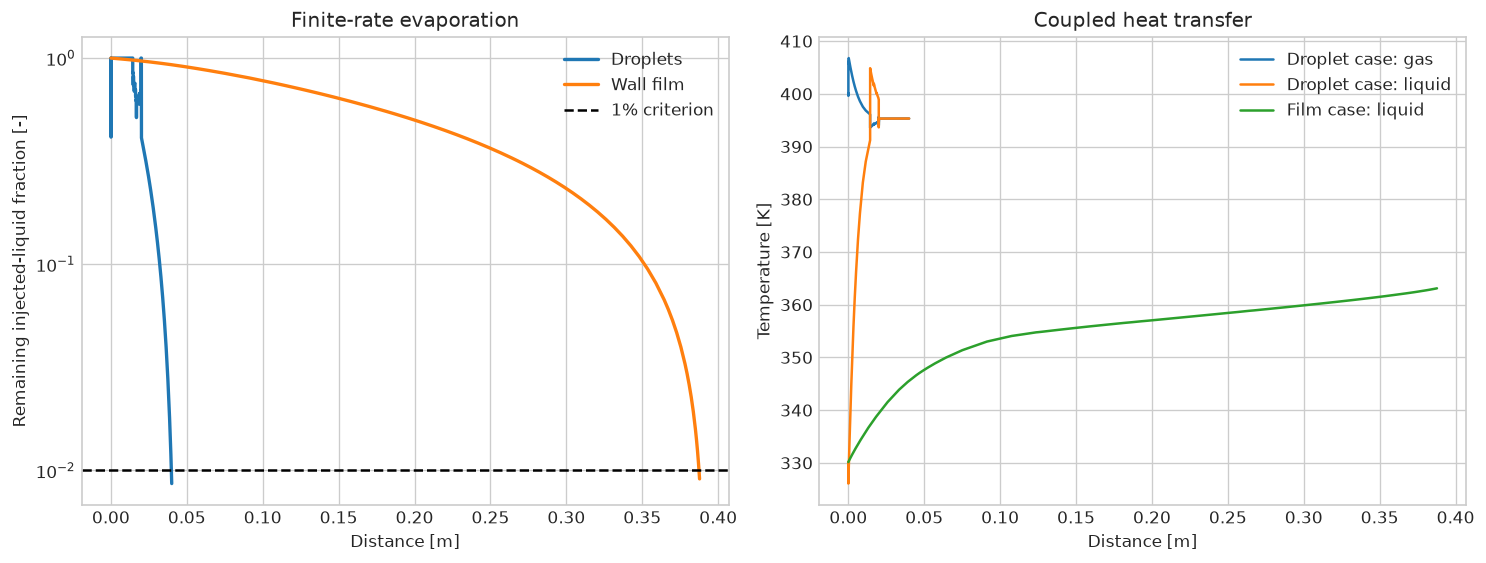

In [6]:
figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12.5, 4.8),
)

for label, frame in {
    "Droplets": droplet_profile,
    "Wall film": film_profile,
}.items():
    axes[0].semilogy(
        frame["distance [m]"],
        frame["remaining tracked fraction [-]"],
        label=label,
        linewidth=2.0,
    )

axes[0].axhline(
    droplet_config.getCompletionFraction(),
    color="black",
    linestyle="--",
    label="1% criterion",
)
axes[0].set_xlabel("Distance [m]")
axes[0].set_ylabel("Remaining injected-liquid fraction [-]")
axes[0].set_title("Finite-rate evaporation")
axes[0].legend()

axes[1].plot(
    droplet_profile["distance [m]"],
    droplet_profile["gas temperature [K]"],
    label="Droplet case: gas",
)
axes[1].plot(
    droplet_profile["distance [m]"],
    droplet_profile["liquid temperature [K]"],
    label="Droplet case: liquid",
)
axes[1].plot(
    film_profile["distance [m]"],
    film_profile["liquid temperature [K]"],
    label="Film case: liquid",
)
axes[1].set_xlabel("Distance [m]")
axes[1].set_ylabel("Temperature [K]")
axes[1].set_title("Coupled heat transfer")
axes[1].legend()

figure.tight_layout()
plt.show()

The geometry comparison is intentionally not a universal ranking.
Droplet diameter, film thickness, liquid rate, wetted perimeter, turbulence,
entrainment, deposition, and wall heat flux all change the area and transfer
coefficients. Use measured or separately predicted morphology inputs where
possible.

A conservative inventory limiter can appear as a solver note when a component
becomes depleted near completion. Treat it as an auditable numerical safeguard,
not a validation result; the component and energy residuals must still pass.

## 2. Gas bubbles dissolving into oil with slip

At 120 bara, methane has a strong equilibrium driving force into the oil. The
finite-rate model still needs bubble area, relative motion, and residence time.

TERMINAL_VELOCITY solves a local Schiller–Naumann force balance. The magnitude
of the terminal relative velocity is used in transfer correlations. Its axial
projection changes phase residence time with pipe inclination. The comparison
case uses specified actual velocities.

In [7]:
oil_terminal_config = make_config(
    pipe_length=0.10,
    gas_velocity=0.50,
    liquid_velocity=0.30,
)
oil_terminal_config.setInitialBubbleDiameter(1.0e-3)
oil_terminal_config.setSlipModel(SlipModel.TERMINAL_VELOCITY)
oil_terminal_config.setPipeInclinationAngle(math.pi / 6.0)

oil_specified_config = make_config(
    pipe_length=0.10,
    gas_velocity=0.50,
    liquid_velocity=0.30,
)
oil_specified_config.setInitialBubbleDiameter(1.0e-3)
oil_specified_config.setSlipModel(SlipModel.USER_SPECIFIED)

oil_terminal_result = DissolutionStudy(
    make_bubbles_in_oil_system(),
    oil_terminal_config,
).run()
oil_specified_result = DissolutionStudy(
    make_bubbles_in_oil_system(),
    oil_specified_config,
).run()

oil_names = component_names(make_bubbles_in_oil_system())
oil_terminal_profile = profile_frame(
    oil_terminal_result,
    oil_names,
)
oil_specified_profile = profile_frame(
    oil_specified_result,
    oil_names,
)

oil_summary = pd.DataFrame(
    [
        result_record("Terminal slip, 30° uphill", oil_terminal_result),
        result_record("Specified phase velocities", oil_specified_result),
    ]
).set_index("case")
display(oil_summary)
print("Terminal-slip solver notes:")
print_warnings(oil_terminal_result)
print("Specified-velocity solver notes:")
print_warnings(oil_specified_result)

Terminal-slip solver notes:
- A closure flux pointed out of a depleted component inventory; a conservative component limiter was applied.
Specified-velocity solver notes:
- A closure flux pointed out of a depleted component inventory; a conservative component limiter was applied.


                            complete  completion distance [m]  outlet remaining fraction [-]  profile points  component residual [mol/s]  relative energy residual [-]  warnings
case                                                                                                                                                                            
Terminal slip, 30° uphill       True                0.0773678                     0.00089725             130                 2.66454e-15                   3.42489e-09         1
Specified phase velocities      True               0.00150001                    0.000566418               5                 8.88178e-16                             0         1

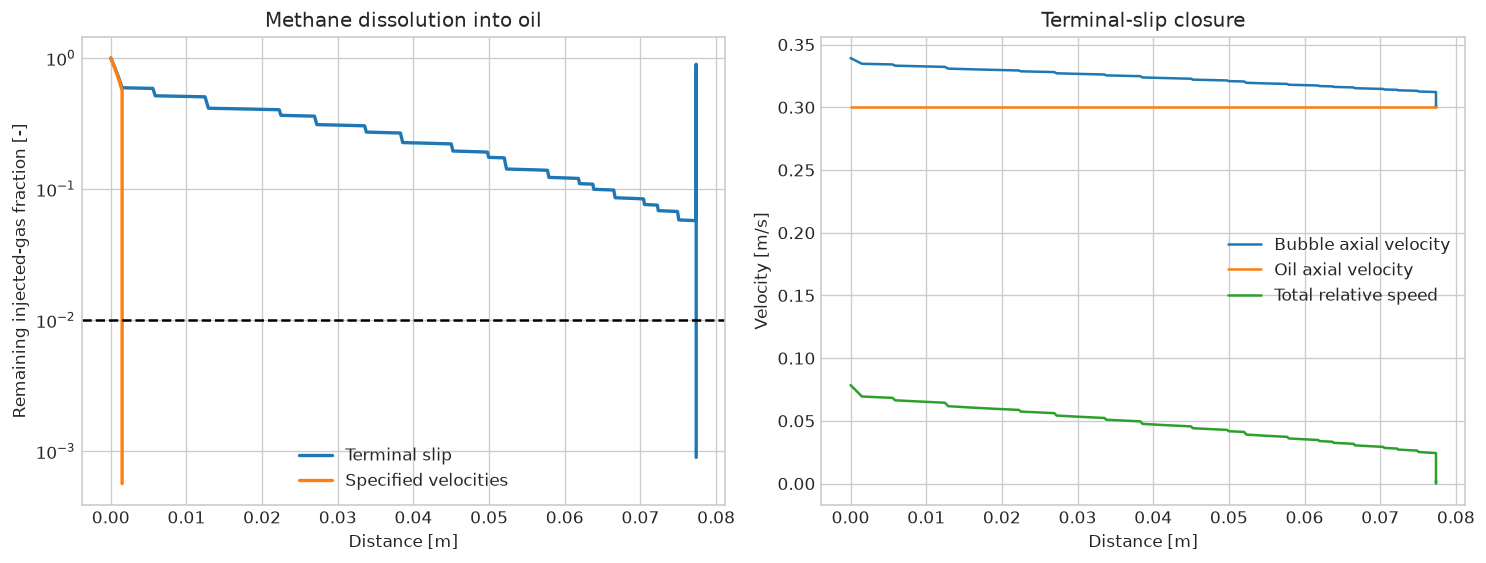

In [8]:
figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12.5, 4.8),
)

for label, frame in {
    "Terminal slip": oil_terminal_profile,
    "Specified velocities": oil_specified_profile,
}.items():
    axes[0].semilogy(
        frame["distance [m]"],
        frame["remaining tracked fraction [-]"],
        label=label,
        linewidth=2.0,
    )

axes[0].axhline(0.01, color="black", linestyle="--")
axes[0].set_xlabel("Distance [m]")
axes[0].set_ylabel("Remaining injected-gas fraction [-]")
axes[0].set_title("Methane dissolution into oil")
axes[0].legend()

axes[1].plot(
    oil_terminal_profile["distance [m]"],
    oil_terminal_profile["gas velocity [m/s]"],
    label="Bubble axial velocity",
)
axes[1].plot(
    oil_terminal_profile["distance [m]"],
    oil_terminal_profile["liquid velocity [m/s]"],
    label="Oil axial velocity",
)
axes[1].plot(
    oil_terminal_profile["distance [m]"],
    oil_terminal_profile["relative velocity [m/s]"],
    label="Total relative speed",
)
axes[1].set_xlabel("Distance [m]")
axes[1].set_ylabel("Velocity [m/s]")
axes[1].set_title("Terminal-slip closure")
axes[1].legend()

figure.tight_layout()
plt.show()

## 3. CO2 bubbles dissolving into water: an incomplete pipe

The aqueous example uses SRK-CPA with the NeqSim CPA mixing rule and explicitly
preserves the aqueous phase type. The short pipe is useful because it demonstrates
the required incomplete behavior: the profile is returned, the outlet remains
two-phase, and the completion distance is NaN.

“Complete solubility” is not a physical rate concept. Equilibrium tells whether
the receiving liquid has capacity for the injected gas at the stated pressure,
temperature, salinity, and composition. This axial calculation tells whether
finite area and residence time are sufficient to approach the chosen inventory
criterion before the pipe outlet.

In [9]:
water_config = make_config(
    pipe_length=0.005,
    gas_velocity=0.50,
    liquid_velocity=0.30,
    maximum_step=0.001,
)
water_config.setInitialBubbleDiameter(0.50e-3)
water_config.setSlipModel(SlipModel.TERMINAL_VELOCITY)

water_result = DissolutionStudy(
    make_bubbles_in_water_system(),
    water_config,
).run()
water_names = component_names(make_bubbles_in_water_system())
water_profile = profile_frame(water_result, water_names)
water_outlet = water_result.getOutletSystem()
water_summary = pd.Series(
    result_record("CO2 into water", water_result),
    name="short aqueous pipe",
)

display(water_summary)
print(
    "Outlet receiving-phase type:",
    str(water_outlet.getPhase(1).getType()),
)
print(
    "Completion distance is NaN:",
    math.isnan(float(water_result.getCompletionDistance())),
)
print_warnings(water_result)

Outlet receiving-phase type: AQUEOUS
Completion distance is NaN: True
- The injected gas did not reach the dissolution criterion within the pipe length.


case                             CO2 into water
complete                                  False
completion distance [m]                     NaN
outlet remaining fraction [-]           0.99991
profile points                                6
component residual [mol/s]          1.38778e-17
relative energy residual [-]        1.19454e-10
warnings                                      1

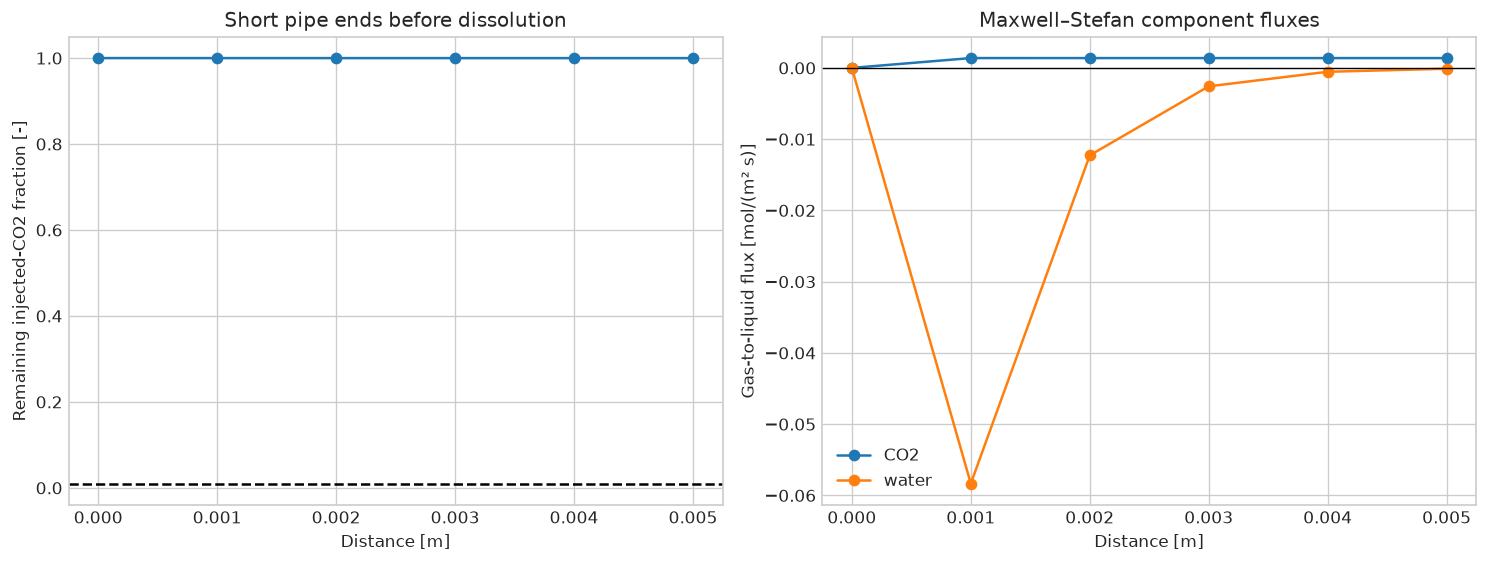

In [10]:
figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12.5, 4.8),
)

axes[0].plot(
    water_profile["distance [m]"],
    water_profile["remaining tracked fraction [-]"],
    marker="o",
)
axes[0].axhline(0.01, color="black", linestyle="--")
axes[0].set_xlabel("Distance [m]")
axes[0].set_ylabel("Remaining injected-CO2 fraction [-]")
axes[0].set_title("Short pipe ends before dissolution")

for component in water_names:
    column = f"{component} flux [mol/(m2 s)]"
    axes[1].plot(
        water_profile["distance [m]"],
        water_profile[column],
        marker="o",
        label=component,
    )

axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xlabel("Distance [m]")
axes[1].set_ylabel("Gas-to-liquid flux [mol/(m² s)]")
axes[1].set_title("Maxwell–Stefan component fluxes")
axes[1].legend()

figure.tight_layout()
plt.show()

## 4. Axial-step sensitivity

Adaptive stepping limits both donor depletion and phase-temperature change in
every accepted step. A practical calculation should still repeat the case with
smaller maximum steps. Here the droplet completion distance is compared on three
step ceilings while all physical inputs stay fixed.

In [11]:
grid_records = []
grid_results = {}

for maximum_step in [0.005, 0.010, 0.020]:
    grid_config = make_config(
        pipe_length=1.0,
        gas_velocity=5.0,
        liquid_velocity=0.5,
        maximum_step=maximum_step,
    )
    grid_config.setInitialDropletDiameter(200.0e-6)
    grid_config.setAmbientTemperature(400.15)
    grid_config.setOverallWallHeatTransferCoefficient(100.0)

    grid_result = EvaporationStudy(
        make_evaporation_system(),
        grid_config,
    ).run()
    grid_results[maximum_step] = grid_result
    record = result_record(
        f"maximum step {maximum_step:g} m",
        grid_result,
    )
    record["maximum step [m]"] = maximum_step
    grid_records.append(record)

grid_table = pd.DataFrame(grid_records).set_index("maximum step [m]")
reference_distance = grid_table.loc[
    0.005,
    "completion distance [m]",
]
grid_table["distance deviation from 0.005 m [%]"] = (
    100.0
    * (
        grid_table["completion distance [m]"]
        - reference_distance
    )
    / reference_distance
)
grid_table

                                  case  complete  completion distance [m]  outlet remaining fraction [-]  profile points  component residual [mol/s]  relative energy residual [-]  warnings  distance deviation from 0.005 m [%]
maximum step [m]                                                                                                                                                                                                                 
0.005             maximum step 0.005 m      True                0.0398042                      0.0086413            6324                 7.37188e-14                   5.92726e-08         1                                    0
0.01               maximum step 0.01 m      True                0.0398042                      0.0086413            6324                 7.37188e-14                   5.92726e-08         1                                    0
0.02               maximum step 0.02 m      True                0.0398042                      0

## 5. Verification checks and machine-readable result

The checks below are deliberately stricter than “the code ran.” They verify
component and energy closure, bounded inventory fractions, expected complete and
incomplete states, preservation of the aqueous phase, and modest step sensitivity.

In [12]:
all_results = [
    droplet_result,
    film_result,
    oil_terminal_result,
    oil_specified_result,
    water_result,
    *grid_results.values(),
]

all_frames = [
    droplet_profile,
    film_profile,
    oil_terminal_profile,
    oil_specified_profile,
    water_profile,
]

checks = {
    "droplet case reaches 1% criterion": (
        droplet_result.isCompleteEvaporation()
    ),
    "oil case reaches 1% dissolution criterion": (
        oil_terminal_result.isCompleteDissolution()
    ),
    "aqueous short pipe remains incomplete": (
        not water_result.isCompleteDissolution()
    ),
    "incomplete completion distance is NaN": math.isnan(
        float(water_result.getCompleteDissolutionDistance())
    ),
    "aqueous phase type is preserved": (
        str(water_outlet.getPhase(1).getType()) == "AQUEOUS"
    ),
    "component residuals are below 1e-10 mol/s": all(
        result.getMaximumComponentMolarBalanceError() < 1.0e-10
        for result in all_results
    ),
    "relative energy residuals are below 1e-5": all(
        result.getRelativeEnergyBalanceError() < 1.0e-5
        for result in all_results
    ),
    "tracked fractions remain bounded": all(
        frame["remaining tracked fraction [-]"].between(
            0.0,
            1.0,
        ).all()
        for frame in all_frames
    ),
    "step sensitivity is within 2%": (
        grid_table[
            "distance deviation from 0.005 m [%]"
        ].abs().max()
        < 2.0
    ),
}

check_table = pd.Series(checks, name="passed").to_frame()
display(check_table)
assert all(checks.values())

print(f"All {len(checks)} engineering checks passed.")

All 9 engineering checks passed.


                                           passed
droplet case reaches 1% criterion            True
oil case reaches 1% dissolution criterion    True
aqueous short pipe remains incomplete        True
incomplete completion distance is NaN        True
aqueous phase type is preserved              True
component residuals are below 1e-10 mol/s    True
relative energy residuals are below 1e-5     True
tracked fractions remain bounded             True
step sensitivity is within 2%                True

In [13]:
def clean_records(frame):
    return (
        frame.reset_index()
        .replace({np.nan: None})
        .to_dict(orient="records")
    )


machine_readable_results = {
    "neqsim_build": NEQSIM_BUILD,
    "neqsim_source_commit": REQUIRED_NEQSIM_COMMIT,
    "completion_definition": "remaining tracked mass fraction <= 0.01",
    "evaporation_cases": clean_records(evaporation_summary),
    "oil_dissolution_cases": clean_records(oil_summary),
    "aqueous_incomplete_case": water_summary.replace(
        {np.nan: None}
    ).to_dict(),
    "grid_sensitivity": clean_records(grid_table),
    "checks_passed": int(sum(checks.values())),
}

print(
    json.dumps(
        machine_readable_results,
        indent=2,
        sort_keys=True,
    )
)

{
  "aqueous_incomplete_case": {
    "case": "CO2 into water",
    "complete": false,
    "completion distance [m]": null,
    "component residual [mol/s]": 1.3877787807814457e-17,
    "outlet remaining fraction [-]": 0.9999098252929303,
    "profile points": 6,
    "relative energy residual [-]": 1.1945401512102098e-10,
    "warnings": 1
  },
  "checks_passed": 9,
  "completion_definition": "remaining tracked mass fraction <= 0.01",
  "evaporation_cases": [
    {
      "case": "Droplets",
      "complete": true,
      "completion distance [m]": 0.03980422419276055,
      "component residual [mol/s]": 7.37188088351104e-14,
      "outlet remaining fraction [-]": 0.00864130212610353,
      "profile points": 6324,
      "relative energy residual [-]": 5.927258461649248e-08,
      "warnings": 1
    },
    {
      "case": "Wall film",
      "complete": true,
      "completion distance [m]": 0.38735044326484747,
      "component residual [mol/s]": 8.881784197001252e-16,
      "outlet remaini

## Interpretation, validation status, and limits

Use the reported distance only after checking the model basis:

- **Thermodynamic capacity:** perform a separate equilibrium flash or solubility
  study at representative local pressure, temperature, composition, and salinity.
- **Morphology:** droplet/bubble size and film thickness are inputs here. Coalescence,
  breakup, entrainment, deposition, and film dryout are not population-balanced.
- **Hydrodynamics:** phase velocities are supplied. Terminal slip is a local
  Schiller–Naumann closure, not a complete mechanistic multiphase pressure-drop model.
- **Pressure:** this study holds pressure fixed. Couple to a hydraulic pipeline
  model when pressure loss materially changes equilibrium or properties.
- **Completion:** choose a defensible tolerance such as 1%, 0.1%, or an outlet
  concentration specification. Exact zero is not numerically or physically useful.
- **Validation:** this notebook demonstrates conservation, limiting behavior,
  phase-type preservation, and step convergence. It does **not** claim validation
  against a proprietary simulator or a universal evaporation/dissolution dataset.
  Project use should compare against matched pipe-loop or spray/bubble-column data
  and an independent tool on the same thermodynamic, area, slip, and heat-loss basis.

Useful independent comparisons include a plug-flow $k_La$ model for dissolution,
a $d^2$-law screen for isolated droplets, and commercial multiphase simulators.
Agreement is meaningful only if interfacial area, residence time, boundary
conditions, and property packages are aligned.

### References

- [NeqSim finite-rate pipeline phase-transfer PR](https://github.com/equinor/neqsim/pull/2519)
- R. Krishna and J. A. Wesselingh, “The Maxwell–Stefan approach to mass transfer,”
  *Chemical Engineering Science* 52 (1997), 861–911,
  [doi:10.1016/S0009-2509(96)00458-7](https://doi.org/10.1016/S0009-2509(96)00458-7).
- B. Abramzon and W. A. Sirignano, “Droplet vaporization model for spray
  combustion calculations,” *International Journal of Heat and Mass Transfer*
  32 (1989), 1605–1618,
  [doi:10.1016/0017-9310(89)90043-4](https://doi.org/10.1016/0017-9310(89)90043-4).

### Suggested extensions

Try bubble or droplet diameter sweeps, salinity, changing pressure, different
completion tolerances, heat-transfer coefficients, and uphill/downhill inclination.
For design work, propagate uncertain size and slip inputs as ranges rather than
reporting one falsely precise length.